In [1]:
from pathlib import Path
from exif import Image as ExifImage
import numpy as np
import cv2
from matplotlib import pyplot as plt

Data Loading

In [2]:
jpg_folder = Path("hdr-jpg/")
jpg_sorted_files = sorted(jpg_folder.glob("*JPG"))
jpg_data_str = list(str(f) for f in jpg_sorted_files)

In [3]:
images = []
exposure_time = []
for i in range(len(jpg_data_str)):
    image = cv2.imread(jpg_data_str[i])
    exif_data = ExifImage(jpg_data_str[i])
    exposure = exif_data.exposure_time
    images.append(image)
    exposure_time.append(exposure)

In [4]:
exposure_time

[13.0, 6.0, 3.2, 1.6, 0.8, 0.4, 0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625]

In [5]:
def calculate_pixel_mean(im):
    """ Calcuate the pixel mean of the entire image """   
    return np.mean(im)
means = []
for j in range(len(images)):
    means.append(calculate_pixel_mean(images[j]))


In [6]:
print(f"exposure: {exposure_time}")
print(f"Means: {means}")

exposure: [13.0, 6.0, 3.2, 1.6, 0.8, 0.4, 0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625]
Means: [227.09749540277778, 196.45685429166667, 157.7389222777778, 122.694213375, 87.1428657361111, 56.696055791666666, 34.63237556944444, 22.413326402777777, 12.636881944444445, 8.508006694444445, 4.15413975, 1.707783736111111]


Visualization the non-linear data

Text(0.5, 1.0, 'Mean Pixel Value vs Exposure Time')

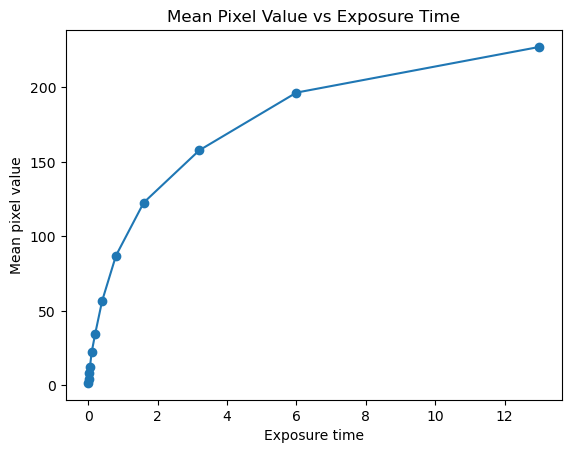

In [7]:
# plot to check nonlinearity
plt.plot(exposure_time, means, 'o-')
plt.xlabel("Exposure time")
plt.ylabel("Mean pixel value")
plt.title("Mean Pixel Value vs Exposure Time")

Finding the gamma value

In [ ]:
def norm_img(img):
    """ Normalize image for visualization """
    a = np.percentile(img, 0.01)
    b = np.percentile(img, 99.99)
    norm_image = (img - a)/ (b-a)
    norm_image[norm_image<0] = 0
    norm_image[norm_image>1] = 1
    return norm_image

In [9]:
log_exposures = np.log(np.array(exposure_time))
log_means = np.log(np.array(means))

In [10]:
slope, intercept = np.polyfit(log_exposures, log_means, 1)

In [11]:
gamma_est = 1.0 / slope

In [12]:
print(f"Estimated gamma: {gamma_est}")

Estimated gamma: 1.5841479473421112


Linearizing the images

In [13]:
def inverse_gamma(img, gamma):
    linear_img = norm_img(img) ** (1/gamma)
    return linear_img

In [14]:
linear_images = []
for k in range(len(images)):
    linear_images.append(inverse_gamma(images[k], gamma_est))

Text(0, 0.5, 'Mean Pixel Value')

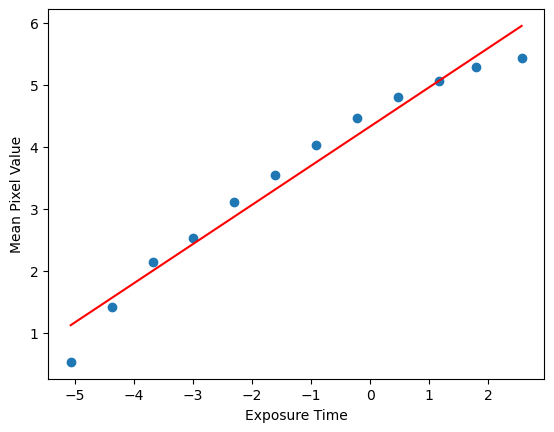

In [15]:
lin_means = []
for j in range(len(linear_images)):
    lin_means.append(calculate_pixel_mean(linear_images[j]))
plt.scatter(log_exposures, log_means, label="Data Points")
plt.plot(log_exposures, slope*log_exposures + intercept, 'r-')
plt.xlabel("Exposure Time")
plt.ylabel("Mean Pixel Value")

Applying the HDR Algorithm to the linearized data

In [16]:
def hdr_jpg(data_str, exp_time):
    h_array = np.array(data_str[0], dtype=np.float32)
    exp_time_float = [float(exp) for exp in exp_time]
    for i in range(1, len(data_str)):
        current_img_array = np.array(data_str[i], dtype=np.float32)
        scale = exp_time_float[0]/exp_time_float[i]
        i_scaled = current_img_array * scale
        thresh = 0.8 * np.max(h_array)
        mask = h_array> thresh
        h_array[mask] = i_scaled[mask]
    return h_array

In [17]:
jpg_hdr_img = hdr_jpg(linear_images, exposure_time)


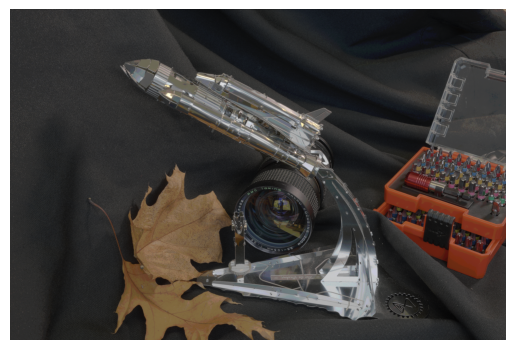

In [18]:
jpg_hdr_img_log = np.log(jpg_hdr_img + 1)
log_min = np.min(jpg_hdr_img_log)
log_max = np.max(jpg_hdr_img_log)
jpg_hdr_img_log_normalized = (jpg_hdr_img_log - log_min) / (log_max - log_min) * 255
jpg_hdr_img_log_normalized = np.clip(jpg_hdr_img_log_normalized, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(cv2.cvtColor(jpg_hdr_img_log_normalized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()